# XGBOOST — Predikcia priemyselnej produkcie SR

In [6]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from xgboost import XGBRegressor
import shap

import functions
importlib.reload(functions)
from functions import make_features, rolling_forecast_xgb, extract_tree_structure, trace_path_for_observation
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


Importy uspesne.


In [7]:
#data
DATA_PATH  = r"C:\Users\adamv\Desktop\ADAM\VS\Diplomovka\excel\data_mod.csv"
SHEET_NAME = "data_mod"
TEST_SIZE = 24
N_LAGS = 3
RANDOM_STATE = 24
df_raw = pd.read_csv(DATA_PATH)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

In [9]:
#definovanie features, train/test vzorka
target = "pp_sa"
exog_cols = ["export_celkovy_sa", "trzby_priemysel_sa", "cpi", "crisis_dummy", "kurz_usd_eur", "unem_prod","inflation"]
features = make_features(data = df, target = target, exog_cols= exog_cols, n_lags = 1)
X = features.drop(columns = [target])
y = features[target]
X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

In [11]:
#tuning hyperparametrov
tscv = TimeSeriesSplit(n_splits=5)

#random_search
random_param_space = {
    "n_estimators": [100, 200, 300, 400, 600],
    "max_depth": [1, 2, 3, 4, 5, 6],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2],
    "gamma": [0, 0.1, 0.5, 1, 5],
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=random_param_space,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)
print("Najlepsie parametre z Random Search:", random_search.best_params_)

best = random_search.best_params_

#grid_search
grid_param_space = {
    "n_estimators": sorted(set([max(50, best["n_estimators"] - 100), best["n_estimators"], best["n_estimators"] + 100])),
    "max_depth": sorted(set([max(1, best["max_depth"] - 1), best["max_depth"], best["max_depth"] + 1])),
    "learning_rate": sorted(set([round(best["learning_rate"] * 0.5, 4), best["learning_rate"], round(best["learning_rate"] * 1.5, 4)])),
    "gamma": sorted(set([max(0, best["gamma"] - 1), best["gamma"], best["gamma"] + 1])),
    "subsample": [best["subsample"]],
    "colsample_bytree": [best["colsample_bytree"]],
    "min_child_weight": [best["min_child_weight"]],
    "reg_alpha": [best["reg_alpha"]],
    "reg_lambda": [best["reg_lambda"]],
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_grid=grid_param_space,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Finalne parametre po Grid Search:", best_params)

Najlepsie parametre z Random Search: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.6}
Finalne parametre po Grid Search: {'colsample_bytree': 0.6, 'gamma': 1.5, 'learning_rate': 0.015, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.6}


In [ ]:
#porovnanie priemerného CV RMSE pre max_depth=1 vs. max_depth=2
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[["param_max_depth", "mean_test_score", "std_test_score"]].sort_values("param_max_depth")

,param_max_depth,mean_test_score,std_test_score
0,1,-3.737602,1.207616
1,1,-3.688947,1.230738
2,1,-3.665731,1.203610
7,1,-3.678620,1.203029
6,1,-3.710546,1.231200
13,1,-3.707576,1.178703
14,1,-3.766881,1.113605
8,1,-3.715439,1.135125
12,1,-3.717173,1.203887
4,2,-3.682287,1.209384


In [12]:
cv_results = pd.DataFrame(grid_search.cv_results_)

depth_summary = (
    cv_results
    .groupby("param_max_depth")
    .agg(
        best_rmse=("mean_test_score", lambda x: -x.max()),
        mean_rmse=("mean_test_score", lambda x: -x.mean()),
        std_cv=("std_test_score", "mean"),
        n_models=("mean_test_score", "count")
    )
    .reset_index()
    .sort_values("best_rmse")
)

depth_summary

,param_max_depth,best_rmse,mean_rmse,std_cv,n_models
1,2,3.471299,3.532455,1.131975,27
2,3,3.475936,3.543351,1.129025,27
0,1,3.484751,3.545062,1.185637,27


In [13]:
#trenovanie a rmse modelu
init_train_size = len(y) - TEST_SIZE
results, last_model = rolling_forecast_xgb(X, y, initial_train_size = init_train_size, refit_every= N_LAGS, objective =  "reg:squarederror", xgb_params=best_params)
rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(f"XGBoost rolling forecast RMSE: {rmse:.4f}")

XGBoost rolling forecast RMSE: 2.1802


In [14]:
init_train_size = len(y) - TEST_SIZE
REFIT_FREQ  = [1,3,5]

In [15]:
#shap
explainer = shap.TreeExplainer(last_model)
shap_values = explainer.shap_values(X_test)
shap_summary = pd.DataFrame(shap_values, columns = X_test.columns, index = X_test.index)
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)
mean_abs_shap

trzby_priemysel_sa         1.077199
export_celkovy_sa          0.562527
pp_sa_lag1                 0.179625
export_celkovy_sa_lag1     0.095581
cpi                        0.072680
cpi_lag1                   0.064864
month                      0.044518
kurz_usd_eur               0.036322
inflation                  0.034939
kurz_usd_eur_lag1          0.028411
trend                      0.028211
inflation_lag1             0.025150
trzby_priemysel_sa_lag1    0.022254
quarter                    0.012381
unem_prod_lag1             0.008031
unem_prod                  0.004525
crisis_dummy               0.000000
crisis_dummy_lag1          0.000000
dtype: float32

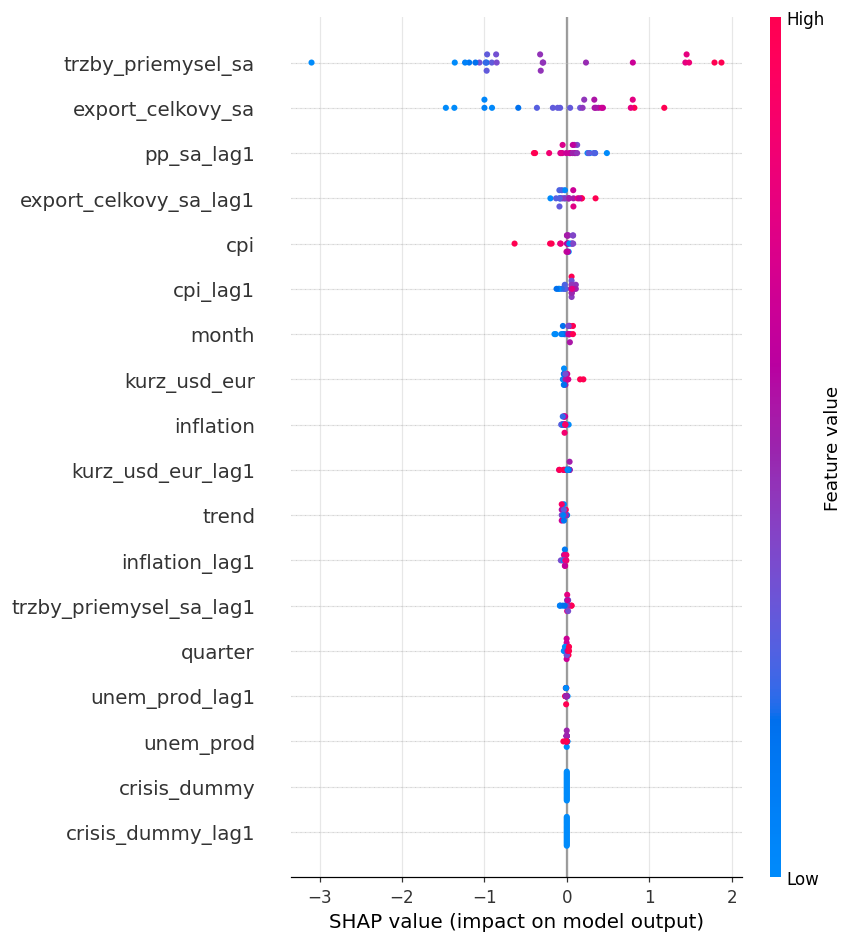

In [16]:
#graf ku shapu
shap.summary_plot(shap_values, X_test)

In [17]:
trees_df = extract_tree_structure(last_model)
trees_df

,Tree,Target,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0,0-0,export_celkovy_sa,84.15,0-1,0-2,0-2,286.9608,172.0,None
1,0,0,1,0-1,pp_sa_lag1,5.48,0-3,0-4,0-4,206.1647,107.0,None
2,0,0,2,0-2,export_celkovy_sa,576.73,0-5,0-6,0-6,61.870544,65.0,None
3,0,0,3,0-3,Leaf,<NA>,<NA>,<NA>,<NA>,-0.008816,101.0,None
4,0,0,4,0-4,Leaf,<NA>,<NA>,<NA>,<NA>,-0.093545,6.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...
1265,199,0,2,199-2,export_celkovy_sa,268.47,199-5,199-6,199-6,45.62436,167.0,None
1266,199,0,3,199-3,Leaf,<NA>,<NA>,<NA>,<NA>,-0.073609,6.0,None
1267,199,0,4,199-4,Leaf,<NA>,<NA>,<NA>,<NA>,-0.005208,11.0,None
1268,199,0,5,199-5,Leaf,<NA>,<NA>,<NA>,<NA>,0.00072,150.0,None


In [18]:
# iba listove uzly (vahy) jedneho konkretneho stromu
tree_0_leaves = trees_df[(trees_df["Tree"] == 0) & (trees_df["Feature"] == "Leaf")]
print(tree_0_leaves[["Tree", "Node", "Gain", "Cover"]])

   Tree  Node      Gain  Cover
3     0     3 -0.008816  101.0
4     0     4 -0.093545    6.0
5     0     5  0.019831   60.0
6     0     6  0.072729    5.0


In [19]:
#najcastejsie pouzivane premenne na delenie
split_counts = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")
    .size()
    .sort_values(ascending=False)
)
print(split_counts)

Feature
trzby_priemysel_sa         131
export_celkovy_sa          123
pp_sa_lag1                  72
cpi                         37
export_celkovy_sa_lag1      37
trend                       19
cpi_lag1                    16
kurz_usd_eur                14
trzby_priemysel_sa_lag1     13
unem_prod                   12
inflation_lag1              12
kurz_usd_eur_lag1           12
month                       12
inflation                   11
unem_prod_lag1              11
quarter                      3
dtype: int64


In [20]:
#priemerny Gain pri deleni podla premennej
avg_gain_by_feature = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")["Gain"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_gain_by_feature)

Feature
trzby_priemysel_sa         153.869815
export_celkovy_sa           132.23348
pp_sa_lag1                  83.447543
cpi                         67.862093
inflation_lag1              64.807654
export_celkovy_sa_lag1      62.376396
kurz_usd_eur_lag1           60.632349
inflation                   60.448013
trend                       60.236919
cpi_lag1                    55.681301
trzby_priemysel_sa_lag1     53.422276
month                       51.594379
unem_prod                   49.859879
quarter                     48.815732
kurz_usd_eur                48.712347
unem_prod_lag1              47.561892
Name: Gain, dtype: Float64


In [21]:
#kompletna struktura jedneho konkretneho stromu
tree_0_full = trace_path_for_observation(trees_df, tree_index=99)
print(tree_0_full)

     Node     Feature  Split   Yes    No      Gain  Cover
643     0  pp_sa_lag1   6.63  99-1  99-2    83.869  187.0
644     1         cpi   1.35  99-3  99-4  46.80484  179.0
645     2        Leaf   <NA>  <NA>  <NA> -0.040188    8.0
646     3        Leaf   <NA>  <NA>  <NA>  0.009457  158.0
647     4        Leaf   <NA>  <NA>  <NA> -0.013714   21.0


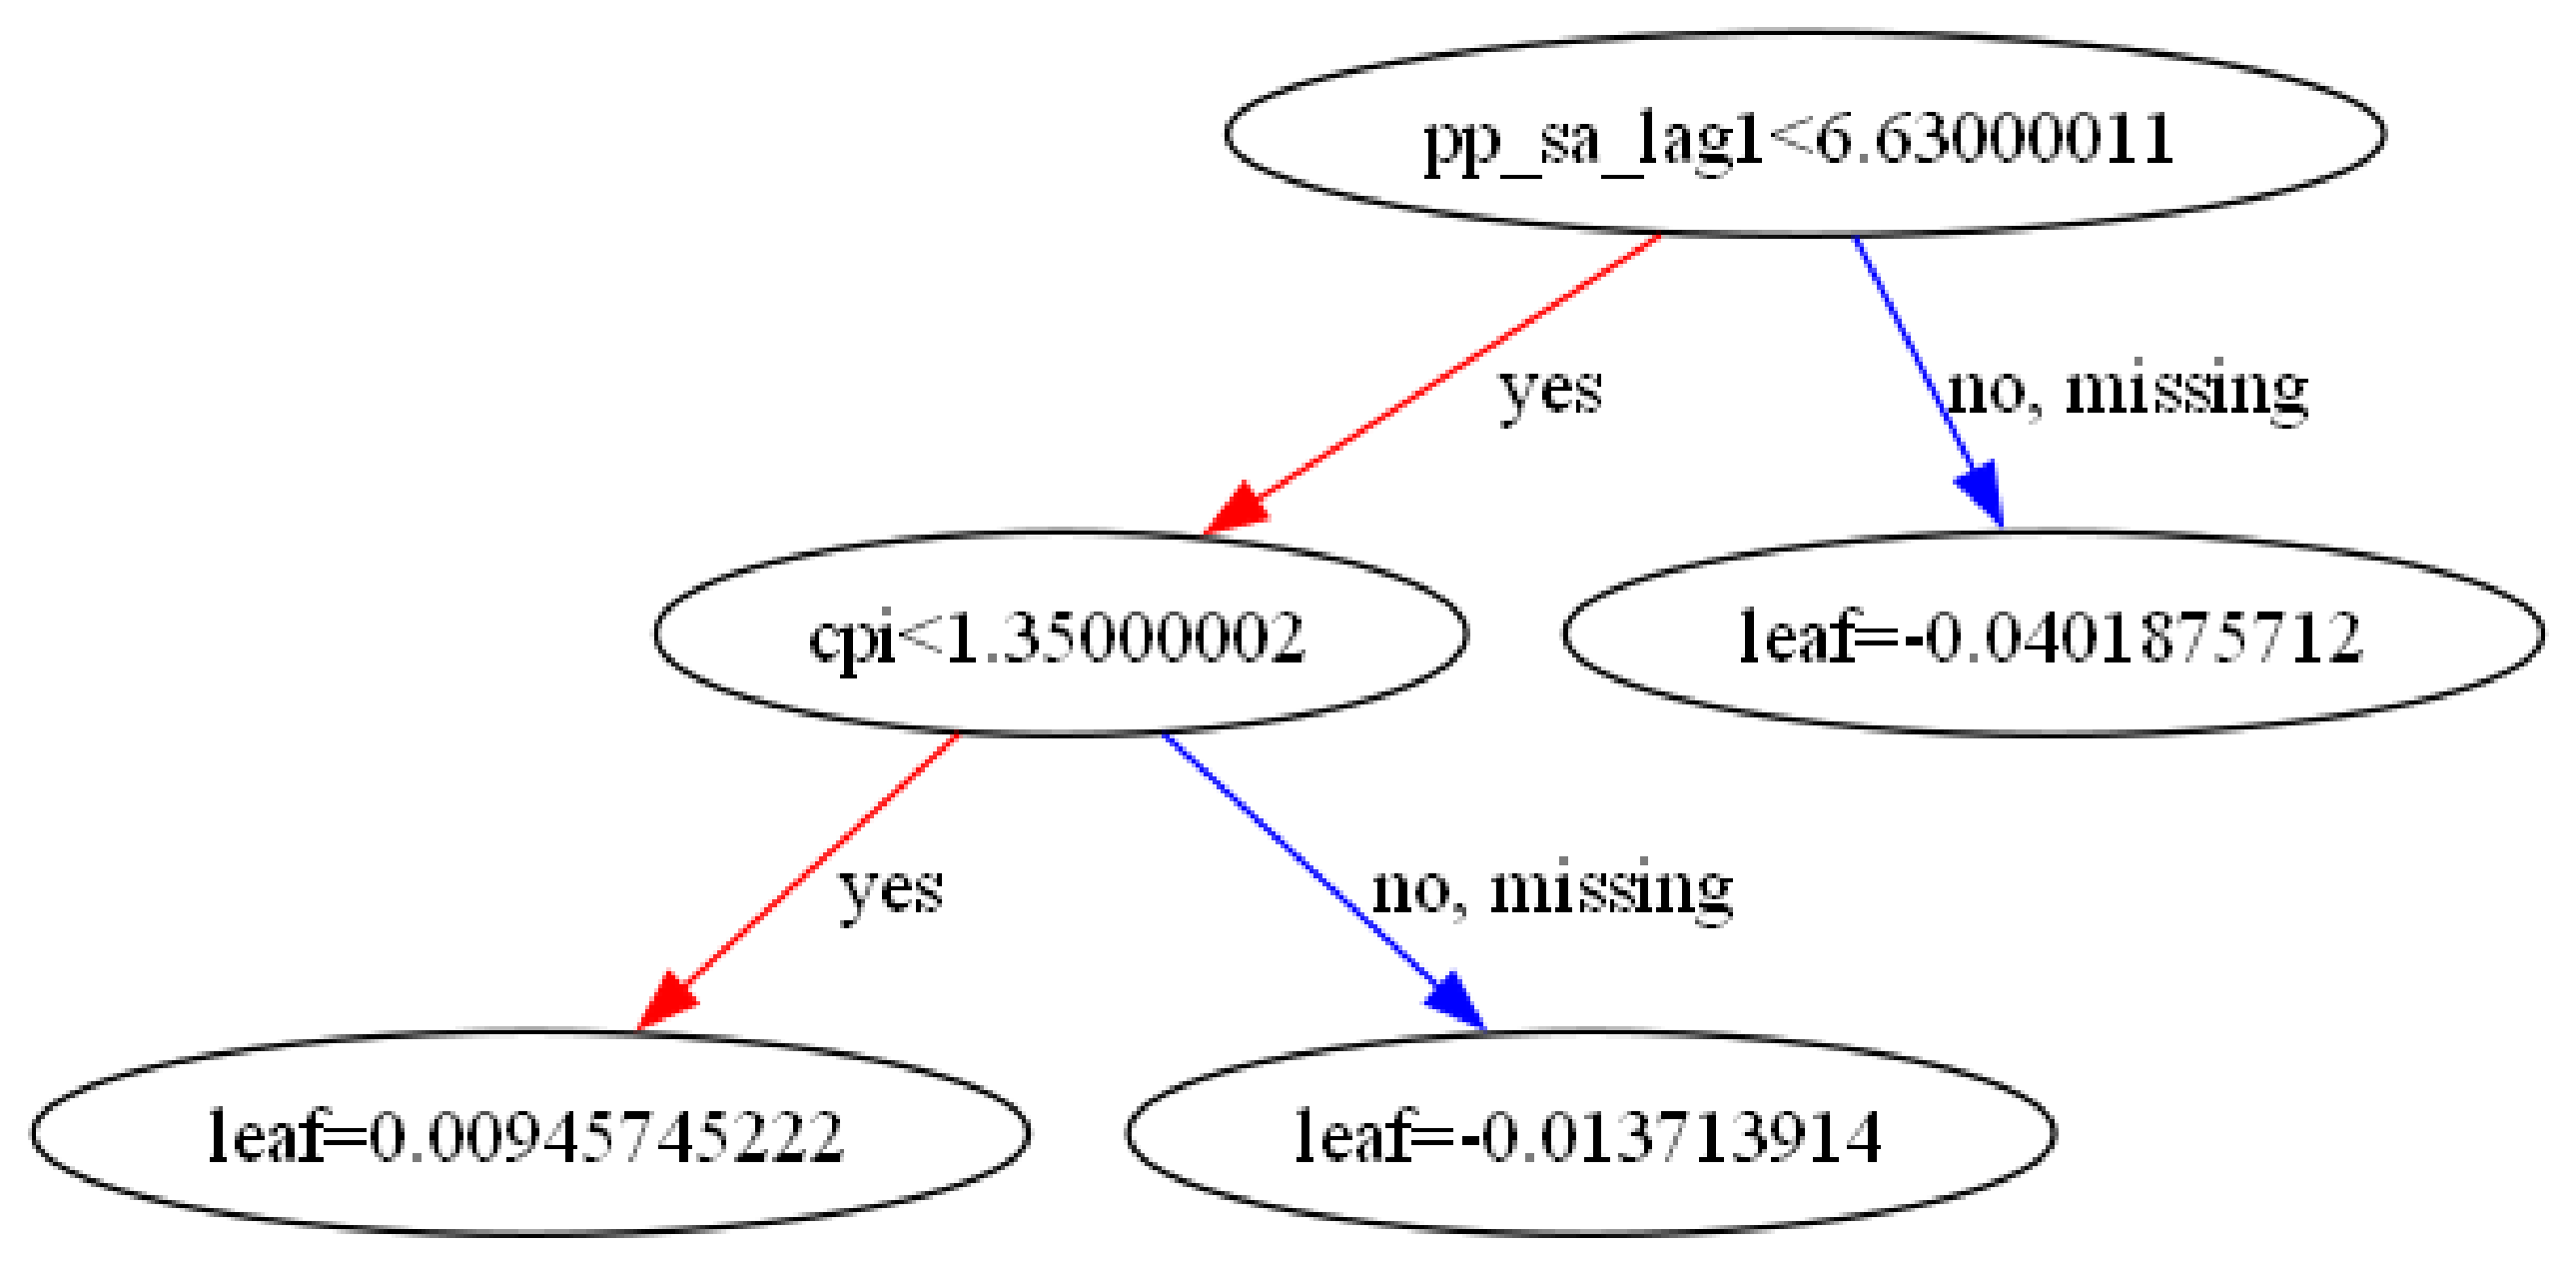

In [22]:
#graficke zobrazenie stromu
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(last_model, num_trees=99)
fig = plt.gcf()
fig.set_size_inches(30, 15)

In [23]:
#Pocet listov a vnutornych uzlov pre kazdy strom
tree_summary = trees_df.groupby("Tree").agg(
    n_nodes=("Node", "count"),
    n_leaves=("Feature", lambda x: (x == "Leaf").sum()),
).reset_index()

# pre binarny strom: n_splits = n_leaves - 1
tree_summary["n_splits"] = tree_summary["n_leaves"] - 1

In [24]:
#Zakladna statistika - kolko stromov ma 0, 1, 2+ deleni
split_distribution = tree_summary["n_splits"].value_counts().sort_index()
print("Rozdelenie poctu deleni naprieč stromami:")
print(split_distribution)

n_trivial = (tree_summary["n_splits"] == 0).sum()
n_single_split = (tree_summary["n_splits"] == 1).sum()
n_multi_split = (tree_summary["n_splits"] > 1).sum()

print(f"\nStromy bez delenia (len 1 list):       {n_trivial}")
print(f"Stromy s presne 1 delenim (2 listy):    {n_single_split}")
print(f"Stromy s viac ako 1 delenim (3+ listy): {n_multi_split}")


Rozdelenie poctu deleni naprieč stromami:
n_splits
2     65
3    135
Name: count, dtype: int64

Stromy bez delenia (len 1 list):       0
Stromy s presne 1 delenim (2 listy):    0
Stromy s viac ako 1 delenim (3+ listy): 200


In [25]:
#ktore konkretne stromy maju viac ako 1 delenie
trees_with_multi_splits = tree_summary[tree_summary["n_splits"] > 1].sort_values(
    "n_splits", ascending=False
)
print("\nStromy s viac ako 1 delenim (zoradene podla poctu deleni):")
print(trees_with_multi_splits)


Stromy s viac ako 1 delenim (zoradene podla poctu deleni):
     Tree  n_nodes  n_leaves  n_splits
0       0        7         4         3
1       1        7         4         3
3       3        7         4         3
4       4        7         4         3
6       6        7         4         3
..    ...      ...       ...       ...
185   185        5         3         2
194   194        5         3         2
192   192        5         3         2
196   196        5         3         2
198   198        5         3         2

[200 rows x 4 columns]


In [26]:
# Priemerny pocet deleni cez cely ansambel - rychly diagnosticky ukazovatel
avg_splits = tree_summary["n_splits"].mean()
pct_trivial = (n_trivial / len(tree_summary)) * 100
print(f"\nPriemerny pocet deleni na strom: {avg_splits:.2f}")
print(f"Podiel trivialnych (nerozdelenych) stromov: {pct_trivial:.1f}%")


Priemerny pocet deleni na strom: 2.67
Podiel trivialnych (nerozdelenych) stromov: 0.0%
